In [1]:
# ============================================================
# Real Estate Market & Affordability Dashboard
# Price-to-Income Analysis across US Metro Areas
# ============================================================

!pip install kaggle -q

import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

kaggle_credentials = {
    "username": "cynthiawanjiku",
    "key": "KGAT_8230434584795821c21884683601bd65"
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download Zillow housing dataset
!kaggle datasets download -d paultimothymooney/zillow-house-price-data --unzip -q

import os
files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("📁 Available CSV files:")
for f in sorted(files):
    print(f"   {f}")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/zillow-house-price-data
License(s): other
📁 Available CSV files:
   City_MedianRentalPrice_1Bedroom.csv
   City_MedianRentalPrice_2Bedroom.csv
   City_MedianRentalPrice_3Bedroom.csv
   City_MedianRentalPrice_4Bedroom.csv
   City_MedianRentalPrice_5BedroomOrMore.csv
   City_MedianRentalPrice_AllHomes.csv
   City_MedianRentalPrice_Sfr.csv
   City_MedianRentalPrice_Studio.csv
   City_Zhvi_1bedroom.csv
   City_Zhvi_2bedroom.csv
   City_Zhvi_3bedroom.csv
   City_Zhvi_4bedroom.csv
   City_Zhvi_5BedroomOrMore.csv
   City_Zhvi_AllHomes.csv
   City_Zhvi_Condominum.csv
   City_Zhvi_SingleFamilyResidence.csv
   City_Zri_AllHomesPlusMultifamily.csv
   City_Zri_SingleFamilyResidenceRental.csv
   DaysOnZillow_City.csv
   DaysOnZillow_State.csv
   Sale_Prices_City.csv
   Sale_Prices_State.csv
   State_MedianRentalPrice_1Bedroom.csv
   State_MedianRentalPrice_2Bedroom.csv
   State_MedianRentalPrice_3Bedroom.csv
   State_MedianRentalPrice_4

In [2]:
# ============================================================
# Load & Shape the Data
# ============================================================

# Load city-level home values (ZHVI = Zillow Home Value Index)
zhvi = pd.read_csv('City_Zhvi_AllHomes.csv', encoding='latin-1')
rental = pd.read_csv('City_MedianRentalPrice_AllHomes.csv', encoding='latin-1')

print(f"✅ ZHVI loaded: {zhvi.shape[0]:,} cities")
print(f"✅ Rental loaded: {rental.shape[0]:,} cities")
print(f"\n📋 ZHVI columns (first 8): {zhvi.columns[:8].tolist()}")
print(f"\n📋 ZHVI columns (last 5): {zhvi.columns[-5:].tolist()}")
print(f"\n🔍 ZHVI sample:")
print(zhvi[['RegionName','State','Metro']].head(5))

✅ ZHVI loaded: 27,330 cities
✅ Rental loaded: 1,699 cities

📋 ZHVI columns (first 8): ['Unnamed: 0', 'RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro']

📋 ZHVI columns (last 5): ['2019-11-30', '2019-12-31', '2020-01-31', '2020-02-29', '2020-03-31']

🔍 ZHVI sample:
    RegionName State                             Metro
0     New York    NY       New York-Newark-Jersey City
1  Los Angeles    CA    Los Angeles-Long Beach-Anaheim
2      Houston    TX  Houston-The Woodlands-Sugar Land
3      Chicago    IL          Chicago-Naperville-Elgin
4  San Antonio    TX         San Antonio-New Braunfels


In [3]:
# ============================================================
# Build Affordability Dataset
# Real median household income by state (ACS 2019)
# ============================================================

# ACS 2019 median household income by state
state_income = {
    'AL': 51734, 'AK': 77640, 'AZ': 62055, 'AR': 47062, 'CA': 80440,
    'CO': 77127, 'CT': 78833, 'DE': 70176, 'FL': 59227, 'GA': 61980,
    'HI': 83102, 'ID': 60999, 'IL': 69187, 'IN': 57603, 'IA': 61836,
    'KS': 59597, 'KY': 52238, 'LA': 51073, 'ME': 58924, 'MD': 87063,
    'MA': 85843, 'MI': 59584, 'MN': 74593, 'MS': 45081, 'MO': 57409,
    'MT': 56539, 'NE': 63229, 'NV': 63276, 'NH': 77933, 'NJ': 85751,
    'NM': 51945, 'NY': 72108, 'NC': 57341, 'ND': 64894, 'OH': 58116,
    'OK': 53840, 'OR': 67058, 'PA': 63463, 'RI': 70305, 'SC': 56227,
    'SD': 59533, 'TN': 56071, 'TX': 64034, 'UT': 74197, 'VT': 63001,
    'VA': 76456, 'WA': 78687, 'WV': 48037, 'WI': 63293, 'WY': 65304,
    'DC': 92266
}

# Get latest home value (2019-12)
price_col = '2019-12-31'

# Build clean dataset
df = zhvi[['RegionName', 'State', 'Metro', 'SizeRank', price_col]].copy()
df.columns = ['city', 'state', 'metro', 'size_rank', 'home_value']
df = df.dropna(subset=['home_value', 'state'])
df = df[df['state'].isin(state_income.keys())]

# Add state income
df['state_median_income'] = df['state'].map(state_income)

# Price-to-income ratio (home value / annual income)
# Standard affordability benchmark: ratio > 5 = unaffordable
df['price_to_income'] = (df['home_value'] / df['state_median_income']).round(2)

# Affordability category
df['affordability'] = df['price_to_income'].apply(
    lambda x: 'Severely Unaffordable (>8x)' if x > 8
    else 'Unaffordable (5-8x)' if x > 5
    else 'Moderately Unaffordable (4-5x)' if x > 4
    else 'Affordable (<4x)'
)

# Region mapping
region_map = {
    'CA': 'West', 'OR': 'West', 'WA': 'West', 'NV': 'West', 'AZ': 'West',
    'UT': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'WY': 'West',
    'AK': 'West', 'HI': 'West',
    'TX': 'South', 'FL': 'South', 'GA': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'TN': 'South', 'AL': 'South',
    'MS': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South',
    'KY': 'South', 'WV': 'South', 'MD': 'South', 'DE': 'South',
    'DC': 'South',
    'NY': 'Northeast', 'NJ': 'Northeast', 'PA': 'Northeast', 'CT': 'Northeast',
    'MA': 'Northeast', 'RI': 'Northeast', 'NH': 'Northeast', 'VT': 'Northeast',
    'ME': 'Northeast',
    'IL': 'Midwest', 'OH': 'Midwest', 'MI': 'Midwest', 'IN': 'Midwest',
    'WI': 'Midwest', 'MN': 'Midwest', 'IA': 'Midwest', 'MO': 'Midwest',
    'KS': 'Midwest', 'NE': 'Midwest', 'SD': 'Midwest', 'ND': 'Midwest',
    'NM': 'South'
}
df['region'] = df['state'].map(region_map)
df = df.dropna(subset=['region'])

# Top cities only (by size rank)
df_top = df[df['size_rank'] <= 500].copy()

print(f"✅ Dataset built: {len(df_top):,} top US cities")
print(f"\n📊 Affordability breakdown:")
print(df_top['affordability'].value_counts().to_string())
print(f"\n💰 Price-to-income stats:")
print(df_top['price_to_income'].describe().round(2))
print(f"\n🏠 Most unaffordable cities:")
print(df_top.nlargest(10, 'price_to_income')[
    ['city','state','home_value','state_median_income','price_to_income']
].to_string(index=False))

✅ Dataset built: 493 top US cities

📊 Affordability breakdown:
affordability
Affordable (<4x)                  240
Unaffordable (5-8x)               127
Moderately Unaffordable (4-5x)     80
Severely Unaffordable (>8x)        46

💰 Price-to-income stats:
count    493.00
mean       4.72
std        2.83
min        0.40
25%        2.97
50%        4.07
75%        5.80
max       20.86
Name: price_to_income, dtype: float64

🏠 Most unaffordable cities:
         city state  home_value  state_median_income  price_to_income
 Santa Monica    CA   1677699.0                80440            20.86
    Sunnyvale    CA   1637341.0                80440            20.35
 Redwood City    CA   1583767.0                80440            19.69
San Francisco    CA   1431606.0                80440            17.80
    San Mateo    CA   1425223.0                80440            17.72
     Berkeley    CA   1304533.0                80440            16.22
  Santa Clara    CA   1279449.0                80440        

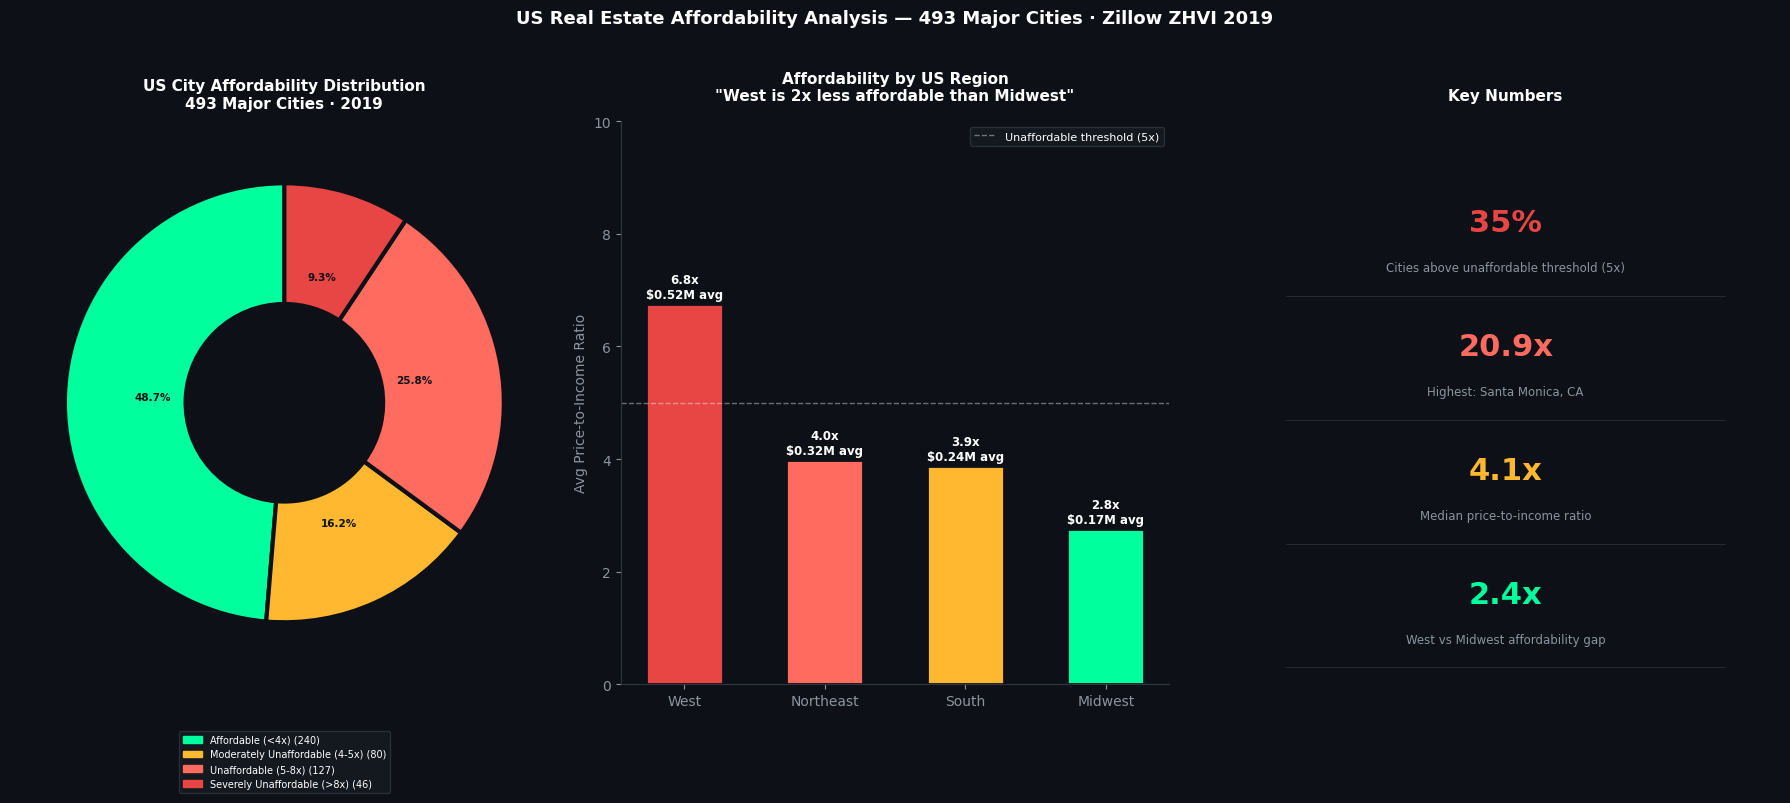

Chart 1 saved


In [4]:
# ============================================================
# Chart 1 — Affordability Overview
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0D1117')

afford_colors = {
    'Affordable (<4x)': '#00FF9D',
    'Moderately Unaffordable (4-5x)': '#FFB830',
    'Unaffordable (5-8x)': '#FF6B5E',
    'Severely Unaffordable (>8x)': '#E84545'
}

# Donut chart
ax1 = axes[0]
ax1.set_facecolor('#0D1117')
counts = df_top['affordability'].value_counts()
order = ['Affordable (<4x)', 'Moderately Unaffordable (4-5x)',
         'Unaffordable (5-8x)', 'Severely Unaffordable (>8x)']
sizes = [counts.get(o, 0) for o in order]
colors = [afford_colors[o] for o in order]
wedges, texts, autotexts = ax1.pie(
    sizes, colors=colors, startangle=90,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.55, edgecolor='#0D1117', linewidth=3),
    textprops=dict(color='white', fontsize=8)
)
for at in autotexts:
    at.set_fontsize(7.5)
    at.set_color('#0D1117')
    at.set_fontweight('bold')
ax1.set_title('US City Affordability Distribution\n493 Major Cities · 2019',
              fontsize=11, fontweight='bold', color='white', pad=15)
patches = [mpatches.Patch(color=afford_colors[o],
           label=f"{o} ({counts.get(o,0)})")
           for o in order]
ax1.legend(handles=patches, fontsize=7, facecolor='#161B22',
           labelcolor='white', edgecolor='#30363D',
           loc='lower center', bbox_to_anchor=(0.5, -0.22))

# Bar: Price-to-income by region
ax2 = axes[1]
ax2.set_facecolor('#0D1117')
region_stats = df_top.groupby('region').agg(
    avg_pti=('price_to_income', 'mean'),
    avg_home=('home_value', 'mean'),
    cities=('city', 'count')
).reindex(['West', 'Northeast', 'South', 'Midwest'])

reg_colors = ['#E84545', '#FF6B5E', '#FFB830', '#00FF9D']
bars = ax2.bar(region_stats.index, region_stats['avg_pti'],
               color=reg_colors, width=0.55,
               edgecolor='#0D1117', linewidth=2)
ax2.axhline(y=5, color='white', linestyle='--',
            linewidth=1, alpha=0.4, label='Unaffordable threshold (5x)')
for bar, (_, row) in zip(bars, region_stats.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{row["avg_pti"]:.1f}x\n${row["avg_home"]/1e6:.2f}M avg',
             ha='center', va='bottom', fontsize=8.5,
             color='white', fontweight='bold')
ax2.set_ylabel('Avg Price-to-Income Ratio', color='#8B949E', fontsize=10)
ax2.set_title('Affordability by US Region\n"West is 2x less affordable than Midwest"',
              fontsize=11, fontweight='bold', color='white', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E')
ax2.set_ylim(0, 10)
ax2.legend(fontsize=8, facecolor='#161B22',
           labelcolor='white', edgecolor='#30363D')

# KPI panel
ax3 = axes[2]
ax3.set_facecolor('#161B22')
ax3.axis('off')
ax3.set_title('Key Numbers', fontsize=11, fontweight='bold',
              color='white', pad=15)
unafford_pct = (df_top['price_to_income'] > 5).sum() / len(df_top) * 100
most_unafford = df_top.nlargest(1, 'price_to_income').iloc[0]
most_afford = df_top.nsmallest(1, 'price_to_income').iloc[0]
west_avg = df_top[df_top['region']=='West']['price_to_income'].mean()
mid_avg = df_top[df_top['region']=='Midwest']['price_to_income'].mean()

kpis = [
    (f'{unafford_pct:.0f}%', 'Cities above unaffordable threshold (5x)', '#E84545'),
    (f'{most_unafford["price_to_income"]:.1f}x', f'Highest: {most_unafford["city"]}, CA', '#FF6B5E'),
    (f'{df_top["price_to_income"].median():.1f}x', 'Median price-to-income ratio', '#FFB830'),
    (f'{west_avg/mid_avg:.1f}x', 'West vs Midwest affordability gap', '#00FF9D'),
]
for i, (num, label, color) in enumerate(kpis):
    y = 0.82 - i * 0.22
    ax3.text(0.5, y, num, ha='center', va='center',
             fontsize=22, fontweight='bold', color=color)
    ax3.text(0.5, y-0.08, label, ha='center', va='center',
             fontsize=8.5, color='#8B949E')
    ax3.axhline(y=y-0.13, xmin=0.1, xmax=0.9,
                color='#30363D', linewidth=0.5)

fig.suptitle('US Real Estate Affordability Analysis — 493 Major Cities · Zillow ZHVI 2019',
             fontsize=13, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('chart_01_affordability_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("Chart 1 saved")

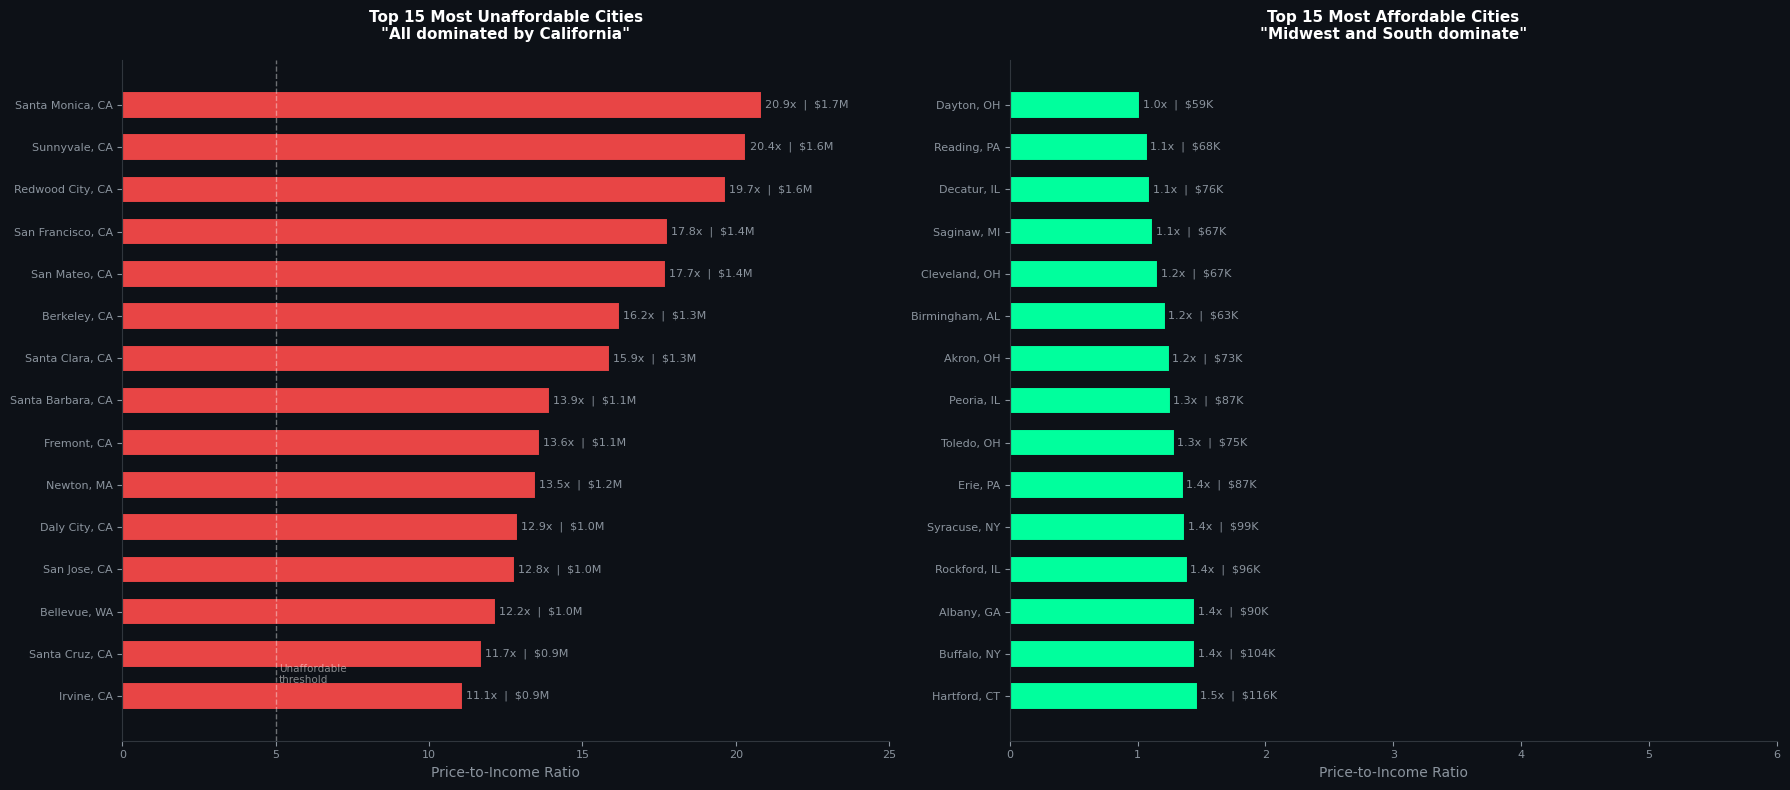

Chart 2 saved


In [5]:
# ============================================================
# Chart 2 — Most & Least Affordable Cities
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0D1117')

#Top 15 most unaffordable
ax1.set_facecolor('#0D1117')
worst = df_top.nlargest(15, 'price_to_income').sort_values('price_to_income')
bar_colors_w = ['#E84545' if r > 8 else '#FF6B5E'
                for r in worst['price_to_income']]

bars1 = ax1.barh(worst['city'] + ', ' + worst['state'],
                 worst['price_to_income'],
                 color=bar_colors_w, height=0.65,
                 edgecolor='#0D1117', linewidth=1.5)
for bar, (_, row) in zip(bars1, worst.iterrows()):
    ax1.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height()/2,
             f'{row["price_to_income"]:.1f}x  |  ${row["home_value"]/1e6:.1f}M',
             va='center', fontsize=8, color='#8B949E')
ax1.axvline(x=5, color='white', linestyle='--',
            linewidth=1, alpha=0.4)
ax1.text(5.1, 0.3, 'Unaffordable\nthreshold',
         color='white', fontsize=7.5, alpha=0.5)
ax1.set_xlabel('Price-to-Income Ratio', color='#8B949E', fontsize=10)
ax1.set_title('Top 15 Most Unaffordable Cities\n"All dominated by California"',
              fontsize=11, fontweight='bold', color='white', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E', labelsize=8)
ax1.set_xlim(0, 25)

# Top 15 most affordable
ax2.set_facecolor('#0D1117')
best = df_top[df_top['home_value'] > 50000].nsmallest(
    15, 'price_to_income').sort_values('price_to_income', ascending=False)
bar_colors_b = ['#00FF9D' if r < 3 else '#00D4AA'
                for r in best['price_to_income']]

bars2 = ax2.barh(best['city'] + ', ' + best['state'],
                 best['price_to_income'],
                 color=bar_colors_b, height=0.65,
                 edgecolor='#0D1117', linewidth=1.5)
for bar, (_, row) in zip(bars2, best.iterrows()):
    ax2.text(bar.get_width() + 0.02,
             bar.get_y() + bar.get_height()/2,
             f'{row["price_to_income"]:.1f}x  |  ${row["home_value"]/1e3:.0f}K',
             va='center', fontsize=8, color='#8B949E')
ax2.set_xlabel('Price-to-Income Ratio', color='#8B949E', fontsize=10)
ax2.set_title('Top 15 Most Affordable Cities\n"Midwest and South dominate"',
              fontsize=11, fontweight='bold', color='white', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E', labelsize=8)
ax2.set_xlim(0, 6)

plt.tight_layout()
plt.savefig('chart_02_best_worst_cities.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("Chart 2 saved")

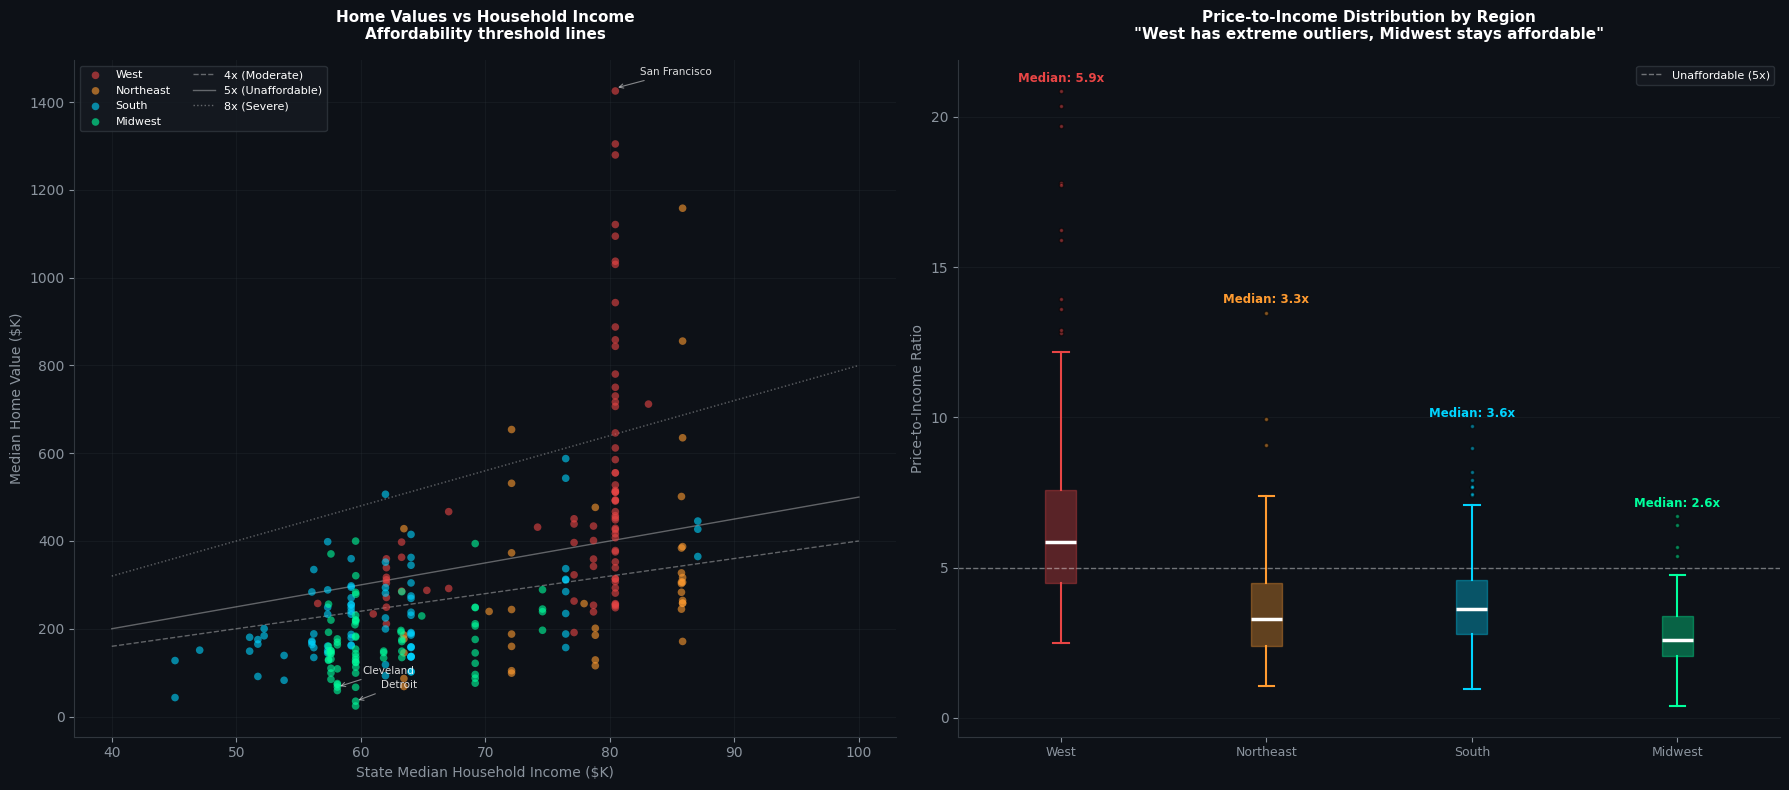

Chart 3 saved


In [6]:
# ============================================================
# Chart 3 — Home Value vs Income Scatter
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0D1117')

# Scatter: home value vs state income
ax1.set_facecolor('#0D1117')
region_colors = {
    'West': '#E84545', 'Northeast': '#FF9B30',
    'South': '#00D4FF', 'Midwest': '#00FF9D'
}

for region, color in region_colors.items():
    mask = df_top['region'] == region
    subset = df_top[mask].sample(min(80, mask.sum()), random_state=42)
    ax1.scatter(
        subset['state_median_income'] / 1000,
        subset['home_value'] / 1000,
        c=color, s=30, alpha=0.6, label=region,
        edgecolors='none', zorder=3
    )

# Affordability lines
income_range = np.linspace(40, 100, 100)
for mult, label, style in [(4, '4x (Moderate)', '--'),
                             (5, '5x (Unaffordable)', '-'),
                             (8, '8x (Severe)', ':')]:
    ax1.plot(income_range, income_range * mult,
             color='white', linestyle=style,
             linewidth=1, alpha=0.35, label=label)

# Annotate key cities
for city, state in [('Santa Monica', 'CA'), ('San Francisco', 'CA'),
                     ('Detroit', 'MI'), ('Cleveland', 'OH')]:
    row = df_top[(df_top['city'] == city) & (df_top['state'] == state)]
    if len(row) > 0:
        r = row.iloc[0]
        ax1.annotate(f"{city}",
                     xy=(r['state_median_income']/1000, r['home_value']/1000),
                     xytext=(r['state_median_income']/1000 + 2,
                             r['home_value']/1000 + 30),
                     fontsize=7.5, color='white', alpha=0.85,
                     arrowprops=dict(arrowstyle='->', color='white',
                                     lw=0.8, alpha=0.5))

ax1.set_xlabel('State Median Household Income ($K)', color='#8B949E', fontsize=10)
ax1.set_ylabel('Median Home Value ($K)', color='#8B949E', fontsize=10)
ax1.set_title('Home Values vs Household Income\nAffordability threshold lines',
              fontsize=11, fontweight='bold', color='white', pad=15)
ax1.legend(fontsize=8, facecolor='#161B22', labelcolor='white',
           edgecolor='#30363D', ncol=2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')
ax1.grid(True, color='#30363D', alpha=0.25)

# Box plot: PTI by region
ax2.set_facecolor('#0D1117')
regions_order = ['West', 'Northeast', 'South', 'Midwest']
reg_palette = ['#E84545', '#FF9B30', '#00D4FF', '#00FF9D']

for i, (region, color) in enumerate(zip(regions_order, reg_palette)):
    data = df_top[df_top['region'] == region]['price_to_income']
    bp = ax2.boxplot(data, positions=[i],
                     patch_artist=True,
                     boxprops=dict(facecolor=color, alpha=0.35, color=color),
                     medianprops=dict(color='white', linewidth=2.5),
                     whiskerprops=dict(color=color, linewidth=1.5),
                     capprops=dict(color=color, linewidth=1.5),
                     flierprops=dict(marker='o', color=color,
                                     markerfacecolor=color,
                                     markersize=3, alpha=0.5))
    med = data.median()
    ax2.text(i, data.max() + 0.3, f'Median: {med:.1f}x',
             ha='center', fontsize=8.5, color=color, fontweight='bold')

ax2.axhline(y=5, color='white', linestyle='--',
            linewidth=1, alpha=0.4, label='Unaffordable (5x)')
ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(regions_order, color='#8B949E', fontsize=9)
ax2.set_ylabel('Price-to-Income Ratio', color='#8B949E', fontsize=10)
ax2.set_title('Price-to-Income Distribution by Region\n"West has extreme outliers, Midwest stays affordable"',
              fontsize=11, fontweight='bold', color='white', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E')
ax2.grid(True, color='#30363D', alpha=0.25, axis='y')
ax2.legend(fontsize=8, facecolor='#161B22', labelcolor='white',
           edgecolor='#30363D')

plt.tight_layout()
plt.savefig('chart_03_scatter_boxplot.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("Chart 3 saved")

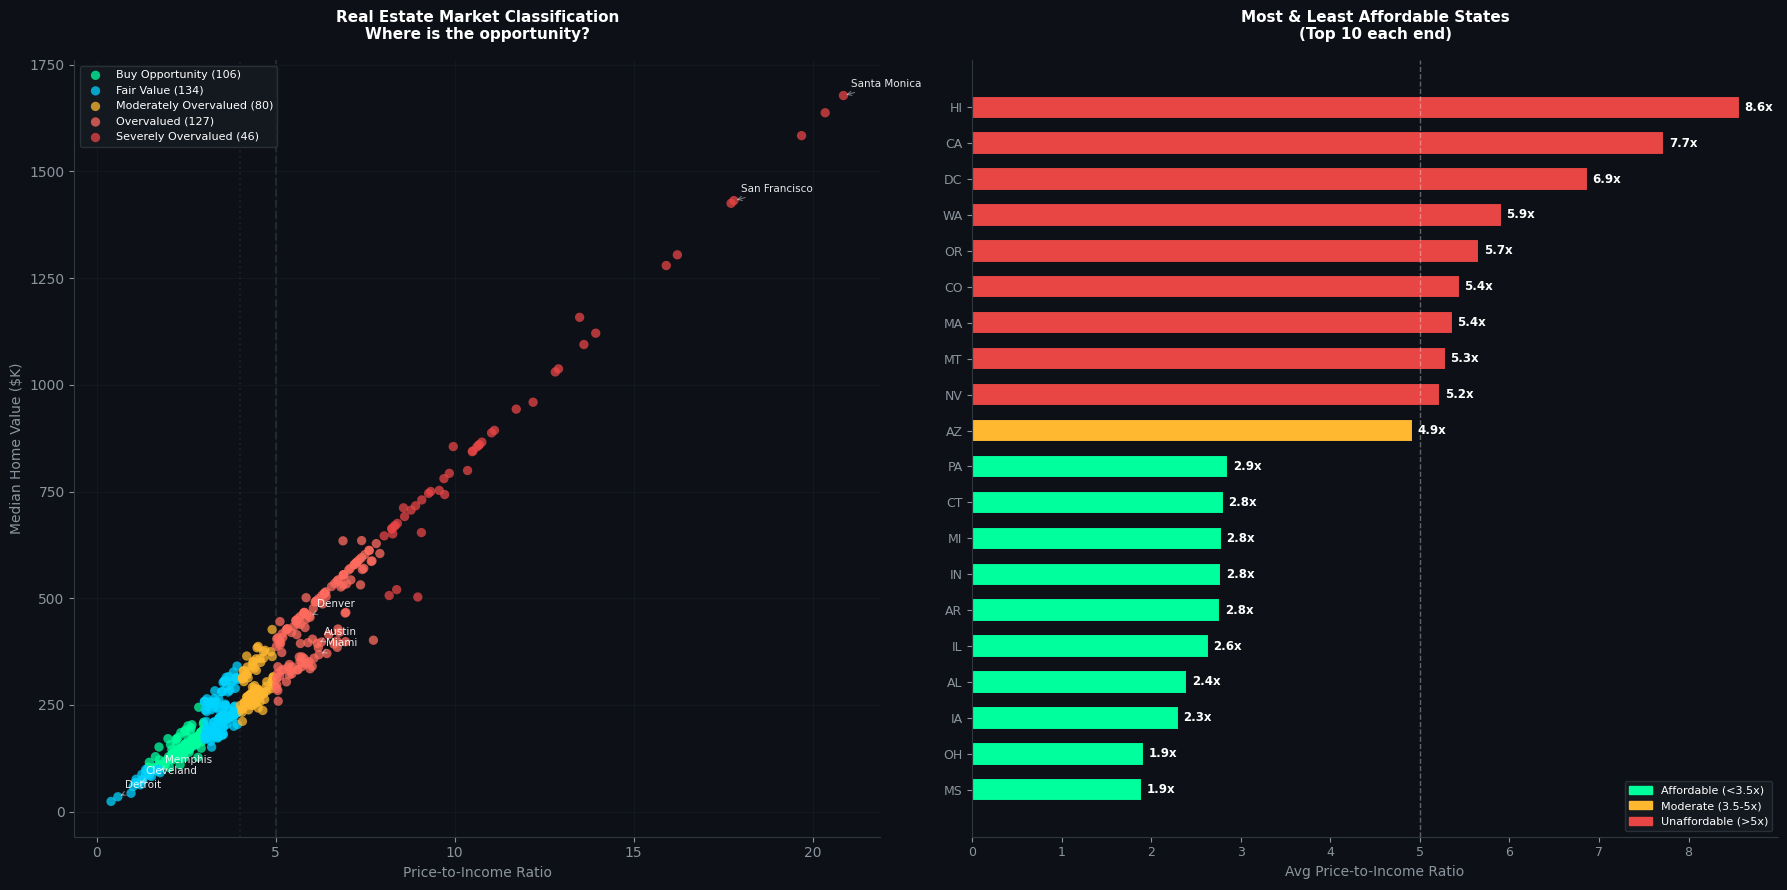

 Chart 4 saved


In [7]:
# ============================================================
# Chart 4 — Investment Opportunity Matrix
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#0D1117')

# Market opportunity scatter
ax1.set_facecolor('#0D1117')

# Classify cities
def classify(row):
    pti = row['price_to_income']
    val = row['home_value']
    if pti < 3 and val > 100000:
        return 'Buy Opportunity'
    elif pti > 8:
        return 'Severely Overvalued'
    elif pti > 5:
        return 'Overvalued'
    elif pti < 4:
        return 'Fair Value'
    else:
        return 'Moderately Overvalued'

df_top['market_class'] = df_top.apply(classify, axis=1)

class_colors = {
    'Buy Opportunity': '#00FF9D',
    'Fair Value': '#00D4FF',
    'Moderately Overvalued': '#FFB830',
    'Overvalued': '#FF6B5E',
    'Severely Overvalued': '#E84545'
}

for cls, color in class_colors.items():
    mask = df_top['market_class'] == cls
    subset = df_top[mask]
    ax1.scatter(
        subset['price_to_income'],
        subset['home_value'] / 1000,
        c=color, s=45, alpha=0.75,
        label=f"{cls} ({mask.sum()})",
        edgecolors='none', zorder=3
    )

# Annotate notable cities
notable = [
    ('Detroit', 'MI'), ('Cleveland', 'OH'), ('Memphis', 'TN'),
    ('San Francisco', 'CA'), ('Santa Monica', 'CA'), ('Austin', 'TX'),
    ('Denver', 'CO'), ('Miami', 'FL')
]
for city, state in notable:
    row = df_top[(df_top['city'] == city) & (df_top['state'] == state)]
    if len(row) > 0:
        r = row.iloc[0]
        ax1.annotate(city,
                     xy=(r['price_to_income'], r['home_value']/1000),
                     xytext=(r['price_to_income'] + 0.2,
                             r['home_value']/1000 + 20),
                     fontsize=7.5, color='white', alpha=0.9,
                     arrowprops=dict(arrowstyle='->', color='white',
                                     lw=0.8, alpha=0.4))

ax1.axvline(x=5, color='#30363D', linestyle='--', alpha=0.6)
ax1.axvline(x=4, color='#30363D', linestyle=':', alpha=0.4)
ax1.set_xlabel('Price-to-Income Ratio', color='#8B949E', fontsize=10)
ax1.set_ylabel('Median Home Value ($K)', color='#8B949E', fontsize=10)
ax1.set_title('Real Estate Market Classification\nWhere is the opportunity?',
              fontsize=11, fontweight='bold', color='white', pad=15)
ax1.legend(fontsize=8, facecolor='#161B22', labelcolor='white',
           edgecolor='#30363D', loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')
ax1.grid(True, color='#30363D', alpha=0.2)

# State heatmap: avg PTI
ax2.set_facecolor('#0D1117')
state_pti = df_top.groupby('state').agg(
    avg_pti=('price_to_income', 'mean'),
    cities=('city', 'count')
).reset_index().sort_values('avg_pti', ascending=True)

top_states = pd.concat([state_pti.head(10), state_pti.tail(10)])
bar_colors_s = ['#00FF9D' if r < 3.5
                else '#FFB830' if r < 5
                else '#E84545'
                for r in top_states['avg_pti']]

bars = ax2.barh(top_states['state'], top_states['avg_pti'],
                color=bar_colors_s, height=0.65,
                edgecolor='#0D1117', linewidth=1.5)
for bar, (_, row) in zip(bars, top_states.iterrows()):
    ax2.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{row["avg_pti"]:.1f}x',
             va='center', fontsize=8.5, color='white', fontweight='bold')

ax2.axvline(x=5, color='white', linestyle='--',
            linewidth=1, alpha=0.35)
ax2.set_xlabel('Avg Price-to-Income Ratio', color='#8B949E', fontsize=10)
ax2.set_title('Most & Least Affordable States\n(Top 10 each end)',
              fontsize=11, fontweight='bold', color='white', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E', labelsize=9)

green = mpatches.Patch(color='#00FF9D', label='Affordable (<3.5x)')
amber = mpatches.Patch(color='#FFB830', label='Moderate (3.5-5x)')
red = mpatches.Patch(color='#E84545', label='Unaffordable (>5x)')
ax2.legend(handles=[green, amber, red], fontsize=8,
           facecolor='#161B22', labelcolor='white', edgecolor='#30363D')

plt.tight_layout()
plt.savefig('chart_04_investment_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print(" Chart 4 saved")

In [8]:
from google.colab import files
files.download('chart_01_affordability_overview.png')
files.download('chart_02_best_worst_cities.png')
files.download('chart_03_scatter_boxplot.png')
files.download('chart_04_investment_matrix.png')
print(" All 4 charts downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All 4 charts downloaded
